Testing Optimized PREC Algorithm
Running 1000 trials of Optimized PREC algorithm...
Completed 100 runs...
Completed 200 runs...
Completed 300 runs...
Completed 400 runs...
Completed 500 runs...
Completed 600 runs...
Completed 700 runs...
Completed 800 runs...
Completed 900 runs...
Valid solutions: 1000/1000 (100.00%)


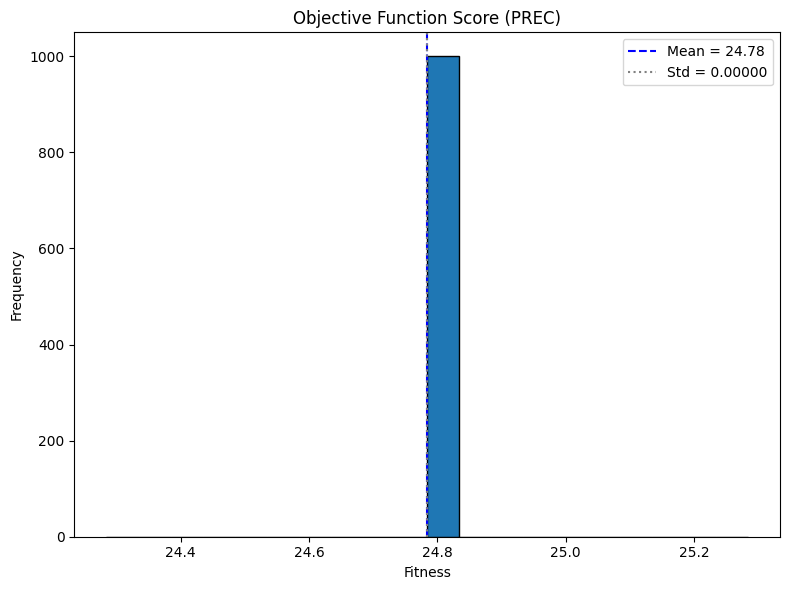

Mean fitness: 24.7841
Std deviation of fitness: 0.0000


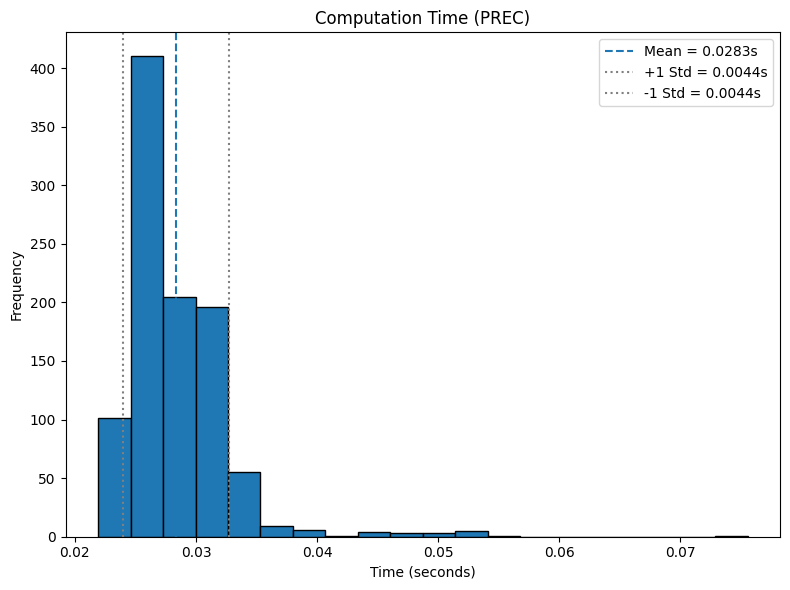

Mean computation time: 0.0283 seconds
Std deviation of time: 0.0044 seconds


In [2]:
import random
import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import time
import logging
from collections import defaultdict
from matplotlib.ticker import ScalarFormatter


logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


base_requests = [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]

distance = [
    [7770, 6896, 9292,  661, 5776, 7770, 6896, 9292,  661, 5776],
    [1360, 9166, 8933, 4797, 2562, 1360, 9166, 8933, 4797, 2562],
    [5890, 9774, 8013, 1495,  564, 5890, 9774, 8013, 1495,  564],
    [5691, 3058, 3112, 8129, 8506, 5691, 3058, 3112, 8129, 8506],
    [6234, 8349, 7541, 9967, 3068, 6234, 8349, 7541, 9967, 3068],
    [6765, 2547, 6735, 1516, 5963, 6765, 2547, 6735, 1516, 5963],
    [ 966, 3247, 5986, 8369, 2527,  966, 3247, 5986, 8369, 2527],
    [4926, 9667, 7599, 6939, 3195, 4926, 9667, 7599, 6939, 3195],
    [6078,  689, 1275, 8392, 5758, 6078,  689, 1275, 8392, 5758],
    [8822, 3234, 8726, 7363, 6118, 8822, 3234, 8726, 7363, 6118],
    [2185, 3505, 3652, 8416, 7236, 2185, 3505, 3652, 8416, 7236],
    [1269, 5158, 2085, 9029,  891, 1269, 5158, 2085, 9029,  891],
    [7449, 2399, 4443, 1378, 6392, 7449, 2399, 4443, 1378, 6392],
    [2933, 8234, 8055, 9768, 4061, 2933, 8234, 8055, 9768, 4061],
    [5811, 1767, 3573, 5387, 6684, 5811, 1767, 3573, 5387, 6684],
    [5551, 2028, 1521, 5359, 3599, 5551, 2028, 1521, 5359, 3599],
    [7561, 3732,  528, 7075,  528, 7561, 3732,  528, 7075,  528],
    [7574, 5977, 8907,  858, 3393, 7574, 5977, 8907,  858, 3393],
    [9117,  102, 2261, 9443,  122, 9117,  102, 2261, 9443,  122],
    [ 801, 8643, 4722,  398, 5485,  801, 8643, 4722,  398, 5485],
]

duration = [
    [537, 199, 471, 838, 395, 537, 199, 471, 838, 395],
    [ 64, 269,  84,  91, 936,  64, 269,  84,  91, 936],
    [741, 807, 588, 796,  71, 741, 807, 588, 796,  71],
    [269,  68, 102, 985, 462, 269,  68, 102, 985, 462],
    [497, 395,  12, 404, 543, 497, 395,  12, 404, 543],
    [995, 385,  38, 996, 660, 995, 385,  38, 996, 660],
    [184, 803,  47, 134, 701, 184, 803,  47, 134, 701],
    [164, 317, 589, 816, 587, 164, 317, 589, 816, 587],
    [649, 636, 151, 395, 893, 649, 636, 151, 395, 893],
    [846,  29, 661, 100, 612, 846,  29, 661, 100, 612],
    [174, 913, 648, 882,  42, 174, 913, 648, 882,  42],
    [142, 404, 108, 625, 768, 142, 404, 108, 625, 768],
    [314, 181, 205, 757, 747, 314, 181, 205, 757, 747],
    [ 76, 703, 716, 898, 333,  76, 703, 716, 898, 333],
    [461, 587,  80,  33, 999, 461, 587,  80,  33, 999],
    [607, 127, 620,  47, 274, 607, 127, 620,  47, 274],
    [677, 205, 311,  81, 731, 677, 205, 311,  81, 731],
    [484, 991,  14, 187, 107, 484, 991,  14, 187, 107],
    [278, 733, 734, 762, 458, 278, 733, 734, 762, 458],
    [269,  85,  50, 893, 180, 269,  85,  50, 893, 180],
]

cum_order = [
    [3.75, 9.34, 6.22, 6.11, 1.01, 3.75, 9.34, 6.22, 6.11, 1.01],
    [9.54, 3.32, 4.06, 4.64, 3.19, 9.54, 3.32, 4.06, 4.64, 3.19],
    [0.36, 3.27, 2.68, 0.34, 0.50, 0.36, 3.27, 2.68, 0.34, 0.50],
    [4.14, 1.80, 2.70, 2.58, 3.42, 4.14, 1.80, 2.70, 2.58, 3.42],
    [3.24, 9.33, 2.17, 4.54, 7.87, 3.24, 9.33, 2.17, 4.54, 7.87],
    [1.39, 2.30, 8.43, 6.29, 1.13, 1.39, 2.30, 8.43, 6.29, 1.13],
    [4.34, 7.15, 3.79, 0.87, 5.05, 4.34, 7.15, 3.79, 0.87, 5.05],
    [9.41, 6.65, 4.07, 8.14, 5.86, 9.41, 6.65, 4.07, 8.14, 5.86],
    [2.46, 3.53, 2.90, 2.97, 4.48, 2.46, 3.53, 2.90, 2.97, 4.48],
    [8.97, 0.24, 9.37, 2.60, 8.02, 8.97, 0.24, 9.37, 2.60, 8.02],
    [1.18, 1.44, 9.76, 6.12, 3.23, 1.18, 1.44, 9.76, 6.12, 3.23],
    [1.42, 1.41, 9.32, 0.54, 2.47, 1.42, 1.41, 9.32, 0.54, 2.47],
    [0.27, 4.19, 0.68, 5.70, 6.18, 0.27, 4.19, 0.68, 5.70, 6.18],
    [4.90, 0.24, 1.13, 4.77, 7.14, 4.90, 0.24, 1.13, 4.77, 7.14],
    [6.26, 6.64, 2.57, 0.19, 4.24, 6.26, 6.64, 2.57, 0.19, 4.24],
    [1.71, 0.54, 6.12, 3.04, 4.12, 1.71, 0.54, 6.12, 3.04, 4.12],
    [7.07, 5.06, 3.26, 0.07, 0.08, 7.07, 5.06, 3.26, 0.07, 0.08],
    [7.60, 9.63, 9.11, 0.26, 8.72, 7.60, 9.63, 9.11, 0.26, 8.72],
    [4.67, 4.10, 9.04, 1.36, 4.38, 4.67, 4.10, 9.04, 1.36, 4.38],
    [1.46, 5.12, 5.58, 2.68, 6.25, 1.46, 5.12, 5.58, 2.68, 6.25],
]

base_order_rate = [26.0, 46.0, 10.0, 19.0, 47.0, 26.0, 46.0, 10.0, 17.0, 47.0]
taxis_battery = [100 for i in range(20)]
battery_threshold = 10


flat_duration = [item for row in duration for item in row]
min_duration = min(flat_duration)
max_duration = max(flat_duration)

flat_cumulative_order_rate = [item for row in cum_order for item in row]
min_cumulative_order_rate = min(flat_cumulative_order_rate)
max_cumulative_order_rate = max(flat_cumulative_order_rate)


min_base_order_rate = min(base_order_rate)
max_base_order_rate = max(base_order_rate)

alpha = 1
beta = 1
gamma = 1

def get_base_map(requests):
    base_requests = defaultdict(int)
    for base_id in requests:
        base_requests[base_id] += 1
    
    unique_bases = list(base_requests.keys())
    base_map = unique_bases
    
    request_to_base_map = []
    base_request_counts = []
    
    for base_id in requests:
        base_index = unique_bases.index(base_id)
        request_to_base_map.append(base_index)
    
    for base_id in unique_bases:
        base_request_counts.append(base_requests[base_id])
    
    return base_map, request_to_base_map, base_request_counts


def get_duplicate_element(individual):
    seen = set()
    duplicates = set()
    for item in individual:
        if item is not None:
            if item in seen:
                duplicates.add(item)
            else:
                seen.add(item)
    return list(duplicates)


def get_unassigned_request(parent, child):
    not_assigned = []
    for i in range(len(parent)):
        if(parent[i] not in child):
            not_assigned.append(parent[i])
    return not_assigned


class PREC:
    def __init__(self, alpha_d=0.0018, alpha_t=0.0014, 
                 battery_threshold=10, reference_set_size=10, c=10, max_chain_length=10):
        self.alpha_d = alpha_d
        self.alpha_t = alpha_t
        self.battery_threshold = battery_threshold
        self.reference_set_size = reference_set_size
        self.c = c
        self.max_chain_length = max_chain_length
        
        
        self.distance_matrix = distance
        self.duration_matrix = duration
        self.cumulative_order_rate_matrix = cum_order
        self.base_order_rates = base_order_rate
        self.taxi_batteries = taxis_battery
        
        
        self.base_map, self.request_to_base_map, self.base_request_counts = get_base_map(base_requests)
    
    def fitness_function(self, taxi_assignments):
        fitness = 0
        miu = 0.1
        
        for i in range(len(taxi_assignments)):
            assigned_base_request = taxi_assignments[i]
            if assigned_base_request is not None:
                order_rate_at_request_base = base_order_rate[assigned_base_request]
                cummulative_order_route = cum_order[i][assigned_base_request]
                estimated_duration= duration[i][assigned_base_request]

                d_hat = max((estimated_duration - min_duration), estimated_duration) / max((max_duration - min_duration), estimated_duration)
                cumulative_hat = 0 if(cummulative_order_route == 0) else max((cummulative_order_route - min_cumulative_order_rate), cummulative_order_route) / max((max_cumulative_order_rate - min_cumulative_order_rate), cummulative_order_route)
                base_order_rate_hat = max((order_rate_at_request_base - min_base_order_rate), order_rate_at_request_base) / max((max_base_order_rate - min_base_order_rate), order_rate_at_request_base)                                                                                
                fir = (alpha * (1- d_hat)) + (beta * (1 - cumulative_hat)) + (gamma * base_order_rate_hat)

                
                fitness_component = fir
                fitness += fitness_component
        
        return fitness
    
    def constraint_satisfied(self, solution):
        
        assigned_requests = [req for req in solution if req is not None]
        if len(assigned_requests) != 10:
            return False
        
        request_counts = [0] * 10
        for req in assigned_requests:
            if req < 0 or req >= 10:
                return False
            request_counts[req] += 1
        
        if any(count != 1 for count in request_counts):
            return False
        
        
        for i in range(len(solution)):
            assignment = solution[i]
            if assignment is not None:
                distance_val = distance[i][assignment]  
                battery_consumption = self.alpha_d * distance_val
                remaining_battery = self.taxi_batteries[i] - battery_consumption
                
                if remaining_battery < self.battery_threshold:
                    return False
        
        return True
    
    def generate_random_solution(self):
        solution = [None] * 20
        available_requests = list(range(10))
        available_taxis = list(range(20))

        
        for _ in range(10):
            best_taxi_idx = None
            best_request_idx = None
            best_incremental_fitness = float('-inf')

            
            for taxi_idx in available_taxis:
                for request_idx in available_requests:
                    
                    temp_solution = solution.copy()
                    temp_solution[taxi_idx] = request_idx

                    
                    distance_val = self.distance_matrix[taxi_idx][request_idx]
                    battery_consumption = self.alpha_d * distance_val
                    remaining_battery = self.taxi_batteries[taxi_idx] - battery_consumption

                    if remaining_battery < self.battery_threshold:
                        continue 

                    current_fitness = self.fitness_function(temp_solution)

                    if current_fitness > best_incremental_fitness:
                        best_incremental_fitness = current_fitness
                        best_taxi_idx = taxi_idx
                        best_request_idx = request_idx
            
            
            if best_taxi_idx is not None and best_request_idx is not None:
                solution[best_taxi_idx] = best_request_idx
                available_taxis.remove(best_taxi_idx)
                available_requests.remove(best_request_idx)
            else:
                break
        
        
        
        if not self.constraint_satisfied(solution):
            repaired_solution = self.repair_solution(solution)
            if repaired_solution is not None:
                return repaired_solution
            else:
                
                basic_solution = [None] * 20
                for i in range(10):
                    basic_solution[i] = i
                if self.constraint_satisfied(basic_solution):
                    return basic_solution
                else:
                    return None 
        
        return solution
    
    def path_relinking(self, solution1, solution2):
        path = []
        current = solution1.copy()
        
        differences = [i for i in range(len(solution1)) if solution1[i] != solution2[i]]
        
        for pos in differences:
            current[pos] = solution2[pos]
            if self.constraint_satisfied(current):
                score = self.fitness_function(current)
                path.append((current.copy(), score))
        
        path.sort(key=lambda x: x[1], reverse=True)
        
        if len(path) > self.c:
            return [sol for sol, _ in path[:self.c]]
        elif len(path) <= 0:
            return [solution1, solution2]
        else:
            return [sol for sol, _ in path]
    
    def ejection_chain(self, solution):
        best_solution = solution.copy()
        best_fitness = self.fitness_function(solution)
        
        num_taxis = len(solution)
        
        for start_taxi in range(len(solution)):
            if solution[start_taxi] is None:
                continue
            
            for chain_length in range(2, min(self.max_chain_length + 1, len(solution))):
                chain_solution = solution.copy()
                visited_taxis = set()
                current_taxi = start_taxi
                current_request = chain_solution[current_taxi]
                
                for step in range(chain_length):
                    available_taxis = [t for t in range(num_taxis) 
                                     if t != current_taxi and t not in visited_taxis 
                                     and chain_solution[t] is not None]
                    
                    if not available_taxis:
                        break
                    
                    next_taxi = random.choice(available_taxis)
                    visited_taxis.add(current_taxi)
                    
                    temp = chain_solution[next_taxi]
                    chain_solution[next_taxi] = current_request
                    current_request = temp
                    current_taxi = next_taxi
                duplicate_chain_sloution = get_duplicate_element(chain_solution)
                unassigned_chain_solution = get_unassigned_request(solution, chain_solution)
                for i in range(len(duplicate_chain_sloution)):
                    duplicate_element = duplicate_chain_sloution[i]
                    duplicate_idx = chain_solution.index(duplicate_element)
                    if(len(unassigned_chain_solution) > 0):
                        chain_solution[duplicate_idx] = unassigned_chain_solution[0]
                        unassigned_chain_solution.remove(unassigned_chain_solution[0])
                    else:
                        chain_solution[duplicate_idx] = None
                for j in range(len(unassigned_chain_solution)):
                    unassigned_element = unassigned_chain_solution[j]
                    none_idx = chain_solution.index(None)
                    chain_solution[none_idx] = unassigned_element
                if self.constraint_satisfied(chain_solution):
                    chain_fitness = self.fitness_function(chain_solution)
                    
                    if chain_fitness > best_fitness:
                        best_solution = chain_solution.copy()
                        best_fitness = chain_fitness
        
        return best_solution
    
    def update_reference_set(self, reference_set, new_solution):
        if not reference_set:
            return reference_set
        
        fitness_list = [self.fitness_function(sol) for sol in reference_set]
        worst_idx = fitness_list.index(min(fitness_list))
        worst_fitness = fitness_list[worst_idx]
        
        new_fitness = self.fitness_function(new_solution)
        
        if new_fitness > worst_fitness and new_solution not in reference_set:
            reference_set[worst_idx] = new_solution.copy()
        
        return reference_set
    
    def run(self, max_iterations=100):
        
        
        reference_set = []

        
        max_attempts = 10
        attempts = 0
        
        while len(reference_set) < self.reference_set_size and attempts < max_attempts:
            random_solution = self.generate_random_solution()
            if self.constraint_satisfied(random_solution):
                reference_set.append(random_solution)
            attempts += 1
        
        if not reference_set:
            return None, None
        
        best_solution = max(reference_set, key=self.fitness_function)
        best_fitness = self.fitness_function(best_solution)
        
        S = []
        
        for iteration in range(max_iterations):
            if len(S) <= 0:
                
                for i in range(len(reference_set)):
                    for j in range(i + 1, len(reference_set)):
                        path = self.path_relinking(reference_set[i], reference_set[j])
                        S.extend(path)
            
            if not S:
                break
            
            
            selected_solution = max(S, key=lambda x: self.fitness_function(x))
            S.remove(selected_solution)
            
            
            ec_solution = self.ejection_chain(selected_solution)
            
            
            reference_set = self.update_reference_set(reference_set, ec_solution)
            
            
            for solution in reference_set:
                fitness_val = self.fitness_function(solution)
                if fitness_val > best_fitness:
                    best_fitness = fitness_val
                    best_solution = solution
        
        return best_solution, best_fitness

def plot_distributions(max_iterations=100, reference_set_size=10, c=10, runs=1000):
    fitness_values = []
    duration_values = []
    valid_runs = 0
    
    print(f"Running {runs} trials of Optimized PREC algorithm...")
    
    for i in range(runs):
        if i % 100 == 0 and i > 0:
            print(f"Completed {i} runs...")
        
        start_time = time.time()
        
        try:
            prec = PREC(reference_set_size=reference_set_size, c=c)
            solution, fitness = prec.run(max_iterations=max_iterations)
            end_time = time.time()
            duration = end_time - start_time
            duration_values.append(duration)
            
            if solution is not None and fitness is not None:
                fitness_values.append(fitness)
                valid_runs += 1
        except Exception as e:
            print(f"Error in run {i}: {str(e)}")
            end_time = time.time()
            duration = end_time - start_time
            duration_values.append(duration)
    
    print(f"Valid solutions: {valid_runs}/{runs} ({valid_runs/runs*100:.2f}%)")

    
    if fitness_values:
        
        fitness_values = np.round(fitness_values, 6)

        mean_fitness = np.mean(fitness_values)
        std_fitness = np.std(fitness_values)


        plt.figure(figsize=(8, 6))

        
        plt.hist(fitness_values, bins=20, edgecolor='black')

        plt.axvline(mean_fitness, linestyle='--', color='blue',
                    label=f'Mean = {mean_fitness:.2f}')
        plt.axvline(mean_fitness + std_fitness, color='gray', linestyle=':',
                    label=f'Std = {std_fitness:.5f}')

        plt.title('Objective Function Score (PREC)')
        plt.xlabel('Fitness')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()

        
        ax = plt.gca()
        ax.ticklabel_format(useOffset=False, style='plain', axis='x')
        ax.xaxis.set_major_formatter(ScalarFormatter())

        plt.show()

        print(f"Mean fitness: {mean_fitness:.4f}")
        print(f"Std deviation of fitness: {std_fitness:.4f}")
    else:
        mean_fitness = None
        std_fitness = None
        print("No valid solutions found to plot fitness distribution.")

    
    if duration_values:
        mean_duration = np.mean(duration_values)
        std_duration = np.std(duration_values)

        plt.figure(figsize=(8, 6))
        plt.hist(duration_values, bins=20, edgecolor='black')
        plt.axvline(mean_duration, linestyle='--', label=f'Mean = {mean_duration:.4f}s')
        plt.axvline(mean_duration + std_duration, color='gray', linestyle=':',
                    label=f'+1 Std = {std_duration:.4f}s')
        plt.axvline(mean_duration - std_duration, color='gray', linestyle=':',
                    label=f'-1 Std = {std_duration:.4f}s')
        plt.title('Computation Time (PREC)'.format(runs))
        plt.xlabel('Time (seconds)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f"Mean computation time: {mean_duration:.4f} seconds")
        print(f"Std deviation of time: {std_duration:.4f} seconds")
    else:
        mean_duration = None
        std_duration = None
        print("No runs completed to plot duration distribution")

    return mean_fitness, std_fitness, mean_duration, std_duration


if __name__ == "__main__":
    print("Testing Optimized PREC Algorithm")
    print("=" * 50)
    
    mean_fitness, std_fitness, mean_duration, std_duration = plot_distributions(
        max_iterations=10,
        reference_set_size=2,
        c=10,
        runs=1000
    )
